# First-Estimation Results: Visualization

Visualizes parameter-estimation results saved as CSVs in `results/first_estimation/`.
This notebook is pure load-from-CSV + plot -- it does NOT import the estimator, does NOT run ipopt, and does NOT rebuild any model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
from matplotlib.patches import Rectangle as MplRect
from matplotlib.transforms import blended_transform_factory
from pathlib import Path

RESULTS_DIR = Path('results/first_estimation')
FIG_DIR = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

ci_df = pd.read_csv(RESULTS_DIR / 'confidence_intervals.csv', index_col=0)
corr_df = pd.read_csv(RESULTS_DIR / 'correlation.csv', index_col=0)
cov_df = pd.read_csv(RESULTS_DIR / 'covariance.csv', index_col=0)
struct_df = pd.read_csv(RESULTS_DIR / 'structural_report_per_parameter.csv', index_col=0)
ident_df = pd.read_csv(RESULTS_DIR / 'structural_report_identifiability.csv', index_col=0)

# Reduced (identifiable-only) covariance / CIs -- well-conditioned, used by the
# forest plot and the CV box plot below.
ci_ident_df = pd.read_csv(RESULTS_DIR / 'confidence_intervals_identifiable.csv', index_col=0)
cov_ident_df = pd.read_csv(RESULTS_DIR / 'covariance_identifiable.csv', index_col=0)

# Stack per-condition sensitivity CSVs into G_stack of shape (n_cond, 18, 37)
sens_files = sorted((RESULTS_DIR / 'sensitivity').glob('*.csv'))
G_list = []
row_kind = None
row_name = None
param_cols = None
cond_names = []

for fp in sens_files:
    df = pd.read_csv(fp)
    if row_kind is None:
        row_kind = df['kind'].tolist()
        row_name = df['name'].tolist()
        param_cols = [c for c in df.columns if c not in ('kind', 'name')]
    else:
        assert df['kind'].tolist() == row_kind, 'row_kind mismatch across conditions'
        assert df['name'].tolist() == row_name, 'row_name mismatch across conditions'
    G_list.append(df[param_cols].values.astype(float))
    cond_names.append(fp.stem)

G_stack = np.stack(G_list, axis=0)  # shape: (n_cond, 18, 37)
print(f'G_stack shape: {G_stack.shape}, conditions: {len(cond_names)}')

PARAMS = list(ci_df.index)
assert PARAMS == list(corr_df.columns), 'PARAMS order mismatch between ci_df and corr_df'
assert PARAMS == param_cols, 'PARAMS order mismatch between ci_df and sensitivity param columns'
print(f'PARAMS verified ({len(PARAMS)} params)')
print(f'Identifiable params loaded ({len(ci_ident_df)}): {list(ci_ident_df.index)}')

G_stack shape: (22, 18, 37), conditions: 22
PARAMS verified (37 params)
Identifiable params loaded (6): ['v_max_1', 'Ka2_1', 'K_g6p_1', 'kcat_f_2', 'kcat_f_3', 'kcat_f_4']


In [2]:
ci_df

,theta,std_err,ci_low,ci_high,cv_percent
v_max_1,30.259090,0.413882,29.447881,31.070300,1.367795
Ka1_1,0.027730,0.014103,0.000089,0.055371,50.857429
Ka2_1,0.069923,0.049350,-0.026803,0.166649,70.577908
Ka3_1,0.417320,0.216991,-0.007983,0.842624,51.996384
K_g6p_1,1.593963,0.462291,0.687872,2.500054,29.002630
Ks_g6p_pgi,0.000144,0.000027,0.000090,0.000197,19.122894
Kp_f6p_pgi,0.910179,3.037205,-5.042742,6.863101,333.693000
kcat_f_2,26.440988,0.660843,25.145737,27.736240,2.499312
Ks_f6p_3,0.229787,0.175241,-0.113684,0.573259,76.262113
Ks_atp_3,0.179204,0.108685,-0.033818,0.392227,60.648674


## Verification: tight CI vs big covariance entry is not a bug

The forest plot shows `v_max_1` with a tight confidence interval while
`covariance.csv` has large entries in the `v_max_1` row. The cell below confirms
these are consistent: each CI standard error equals the square root of the
covariance *diagonal*, and the large numbers live *off* the diagonal (couplings
to non-identifiable parameters whose own variances are enormous). The forest plot
uses only the diagonal, so it is correct -- and below it is rebuilt from the
well-conditioned identifiable-only covariance so the scale is readable.

In [3]:
# VERIFICATION: the CI plot and the covariance matrix are consistent (no bug).
#
# 1. Every CI std_err equals sqrt of the covariance diagonal -- the forest plot
#    uses only that diagonal, so it draws the correct interval.
# 2. The "big entry" in v_max_1's covariance row is OFF-diagonal: it couples
#    v_max_1 to non-identifiable partners whose own variances are astronomical.
#    The marginal CI (diagonal) stays tight while the off-diagonal is huge.
_diag = np.sqrt(np.clip(np.diag(cov_df.to_numpy()), 0.0, None))
assert np.allclose(_diag, ci_df['std_err'].to_numpy(), rtol=1e-6, atol=1e-9), \
    'std_err != sqrt(diag(cov)) -- this WOULD be a bug'
print('OK: ci_df.std_err == sqrt(diag(covariance)) for all 37 params.')

_vd = cov_df.loc['v_max_1', 'v_max_1']
_off = cov_df.loc['v_max_1'].drop('v_max_1').abs()
_pmax = _off.idxmax()
print(f"\nv_max_1 diagonal variance      : {_vd:.3e}  -> std_err {np.sqrt(_vd):.3f}"
      f"  -> CV {ci_df.loc['v_max_1','cv_percent']:.1f}%  (tight, identifiable)")
print(f"v_max_1 largest off-diagonal   : cov[v_max_1, {_pmax}] = {cov_df.loc['v_max_1', _pmax]:.3e}")
print(f"  partner {_pmax} variance      : {cov_df.loc[_pmax, _pmax]:.3e}  (non-identifiable blow-up)")
print("\nConclusion: tight marginal CI + huge off-diagonal entry are both correct;"
      "\nthe forest plot below therefore uses the well-conditioned identifiable-only CIs.")

OK: ci_df.std_err == sqrt(diag(covariance)) for all 37 params.

v_max_1 diagonal variance      : 1.713e-01  -> std_err 0.414  -> CV 1.4%  (tight, identifiable)
v_max_1 largest off-diagonal   : cov[v_max_1, kcat_f_8] = -5.236e+00
  partner kcat_f_8 variance      : 4.025e+03  (non-identifiable blow-up)

Conclusion: tight marginal CI + huge off-diagonal entry are both correct;
the forest plot below therefore uses the well-conditioned identifiable-only CIs.


In [4]:
# Shared style block -- copied verbatim from sensitivity_analysis.ipynb cells 4c2bbb4e and 3bd5d160

import sys, os; sys.path.insert(0, os.path.join(os.path.abspath('.'), 'src'))
from utils import REACTION_GROUPS as reaction_groups, PARAM_LATEX_LABELS as _param_labels_orig, TYPE_COLOR, KCAT0 as _KCAT0, PTS0 as _PTS0
def _t0(i): return 'pts' if i in _PTS0 else ('kcat' if i in _KCAT0 else 'km')
_rank = {'kcat': 0, 'km': 1, 'pts': 0}
_perm = []
for _nm, _is, _ie, _c in reaction_groups:
    _perm += sorted(range(_is, _ie + 1), key=lambda i: (_rank[_t0(i)], i))

param_labels_p = [_param_labels_orig[i] for i in _perm]
KCAT_IDX = {p for p, o in enumerate(_perm) if o in _KCAT0}
PTS_IDX  = {p for p, o in enumerate(_perm) if o in _PTS0}

def _type_color(i):
    if i in PTS_IDX:  return TYPE_COLOR['pts']
    if i in KCAT_IDX: return TYPE_COLOR['kcat']
    return TYPE_COLOR['km']

def styled_matrix_heatmap(M_permuted, vmin, vmax, cbar_label, savepath,
                          cmap_name='RdBu_r', extend='neither',
                          annotate=False, annot_fs=5.0):
    """
    Render a pre-permuted square matrix with the reference styling from
    sensitivity_analysis.ipynb (cell 4c2bbb4e): type-colored ticks, white cell
    gridlines, heavy block separators, colored on-diagonal frames, top+right
    reaction strips, hidden spines, size-matched colorbar, savefig at dpi=300.
    rcParams are saved and restored around the call.
    """
    _rc_save = {k: mpl.rcParams[k] for k in (
        'font.family', 'font.size', 'axes.linewidth', 'mathtext.fontset')}
    mpl.rcParams.update({
        'font.family':     'sans-serif',
        'font.size':        9,
        'axes.linewidth':   0.6,
        'mathtext.fontset': 'dejavusans',
    })

    cmap = mpl.colormaps[cmap_name].copy()
    cmap.set_bad('#e9e9ec')

    GAP      = 0.35
    STRIP    = 1.4
    TICK_FS  = 11
    STRIP_FS = 9

    n = M_permuted.shape[0]
    fig, ax = plt.subplots(figsize=(10.5, 10.5), dpi=200)
    im = ax.imshow(M_permuted, cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='none', aspect='equal')

    ax.set_xlim(-0.5, n - 0.5 + GAP + STRIP)
    ax.set_ylim(n - 0.5, -0.5 - GAP - STRIP)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(param_labels_p, rotation=90, fontsize=TICK_FS, ha='center')
    ax.set_yticklabels(param_labels_p, fontsize=TICK_FS)

    for i, t in enumerate(ax.get_xticklabels()):
        t.set_color(_type_color(i)); t.set_fontweight('semibold')
    for i, t in enumerate(ax.get_yticklabels()):
        t.set_color(_type_color(i)); t.set_fontweight('semibold')
    ax.tick_params(length=2, width=0.5, pad=2)

    for k in np.arange(-0.5, n, 1):
        ax.plot([-0.5, n - 0.5], [k, k], color='white', lw=0.5, zorder=1)
        ax.plot([k, k], [-0.5, n - 0.5], color='white', lw=0.5, zorder=1)

    for name, i_s, i_e, col in reaction_groups:
        if i_s != 0:
            ax.plot([i_s - 0.5, i_s - 0.5], [-0.5, n - 0.5], color='#2b2b2b', lw=1.1, zorder=3)
            ax.plot([-0.5, n - 0.5], [i_s - 0.5, i_s - 0.5], color='#2b2b2b', lw=1.1, zorder=3)
        ax.add_patch(MplRect((i_s - 0.5, i_s - 0.5), i_e - i_s + 1, i_e - i_s + 1,
                             fill=False, edgecolor=col, lw=1.6, zorder=5))
    ax.add_patch(MplRect((-0.5, -0.5), n, n, fill=False, edgecolor='#2b2b2b', lw=1.1, zorder=6))

    top_y   = -0.5 - GAP - STRIP
    right_x = n - 0.5 + GAP
    for name, i_s, i_e, col in reaction_groups:
        w = i_e - i_s + 1
        ax.add_patch(MplRect((i_s - 0.5, top_y), w, STRIP,
                             facecolor=col, edgecolor='white', lw=1.0, zorder=4))
        ax.text((i_s + i_e) / 2, top_y + STRIP / 2, name, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white', zorder=5)
        ax.add_patch(MplRect((right_x, i_s - 0.5), STRIP, w,
                             facecolor=col, edgecolor='white', lw=1.0, zorder=4))
        ax.text(right_x + STRIP / 2, (i_s + i_e) / 2, name, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white', rotation=270, zorder=5)

    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)

    if annotate:
        # Label every finite cell; text color picked for contrast against the
        # underlying RdBu_r color (white on saturated red/blue, black near 0).
        for _r in range(n):
            for _c in range(n):
                _v = M_permuted[_r, _c]
                if not np.isfinite(_v):
                    continue
                _rr, _gg, _bb, _ = im.cmap(im.norm(_v))
                _lum = 0.299 * _rr + 0.587 * _gg + 0.114 * _bb
                ax.text(_c, _r, '%.2f' % _v, ha='center', va='center',
                        fontsize=annot_fs,
                        color='white' if _lum < 0.55 else 'black', zorder=7)

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, shrink=0.6, extend=extend)
    cbar.set_label(cbar_label, fontsize=11, labelpad=4)
    cbar.ax.tick_params(labelsize=9, length=3, width=0.5)
    cbar.outline.set_linewidth(0.6)

    fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

    mpl.rcParams.update(_rc_save)

print('Shared style block loaded.')
print(f'_perm length: {len(_perm)}')
print(f'KCAT_IDX positions: {sorted(KCAT_IDX)}')
print(f'PTS_IDX  positions: {sorted(PTS_IDX)}')

Shared style block loaded.
_perm length: 37
KCAT_IDX positions: [5, 8, 13, 17, 20, 26, 31, 34]
PTS_IDX  positions: [0, 1, 2, 3, 4]


## Sensitivity Analysis

Mean **relative** sensitivity $|d\ln y / d\ln\theta| = |(dy/d\theta)\,\theta_j / y_i|$ averaged over all conditions, split by concentration block (rows 0-8) and flux block (rows 9-17) with separate (log) color scales.

Relative sensitivity rescales the saved absolute sensitivities by the fitted parameter value $\theta_j$ and the predicted output magnitude $y_i$, giving a dimensionless, comparable-across-outputs measure. All 9 balanced metabolite concentrations have finite model predictions (including previously-unmeasured C_g3p, C_pgp, C_2pg), so all rows are normalized and appear in the heatmap. Individual cells whose relative sensitivity falls below the magnitude threshold are still rendered grey.

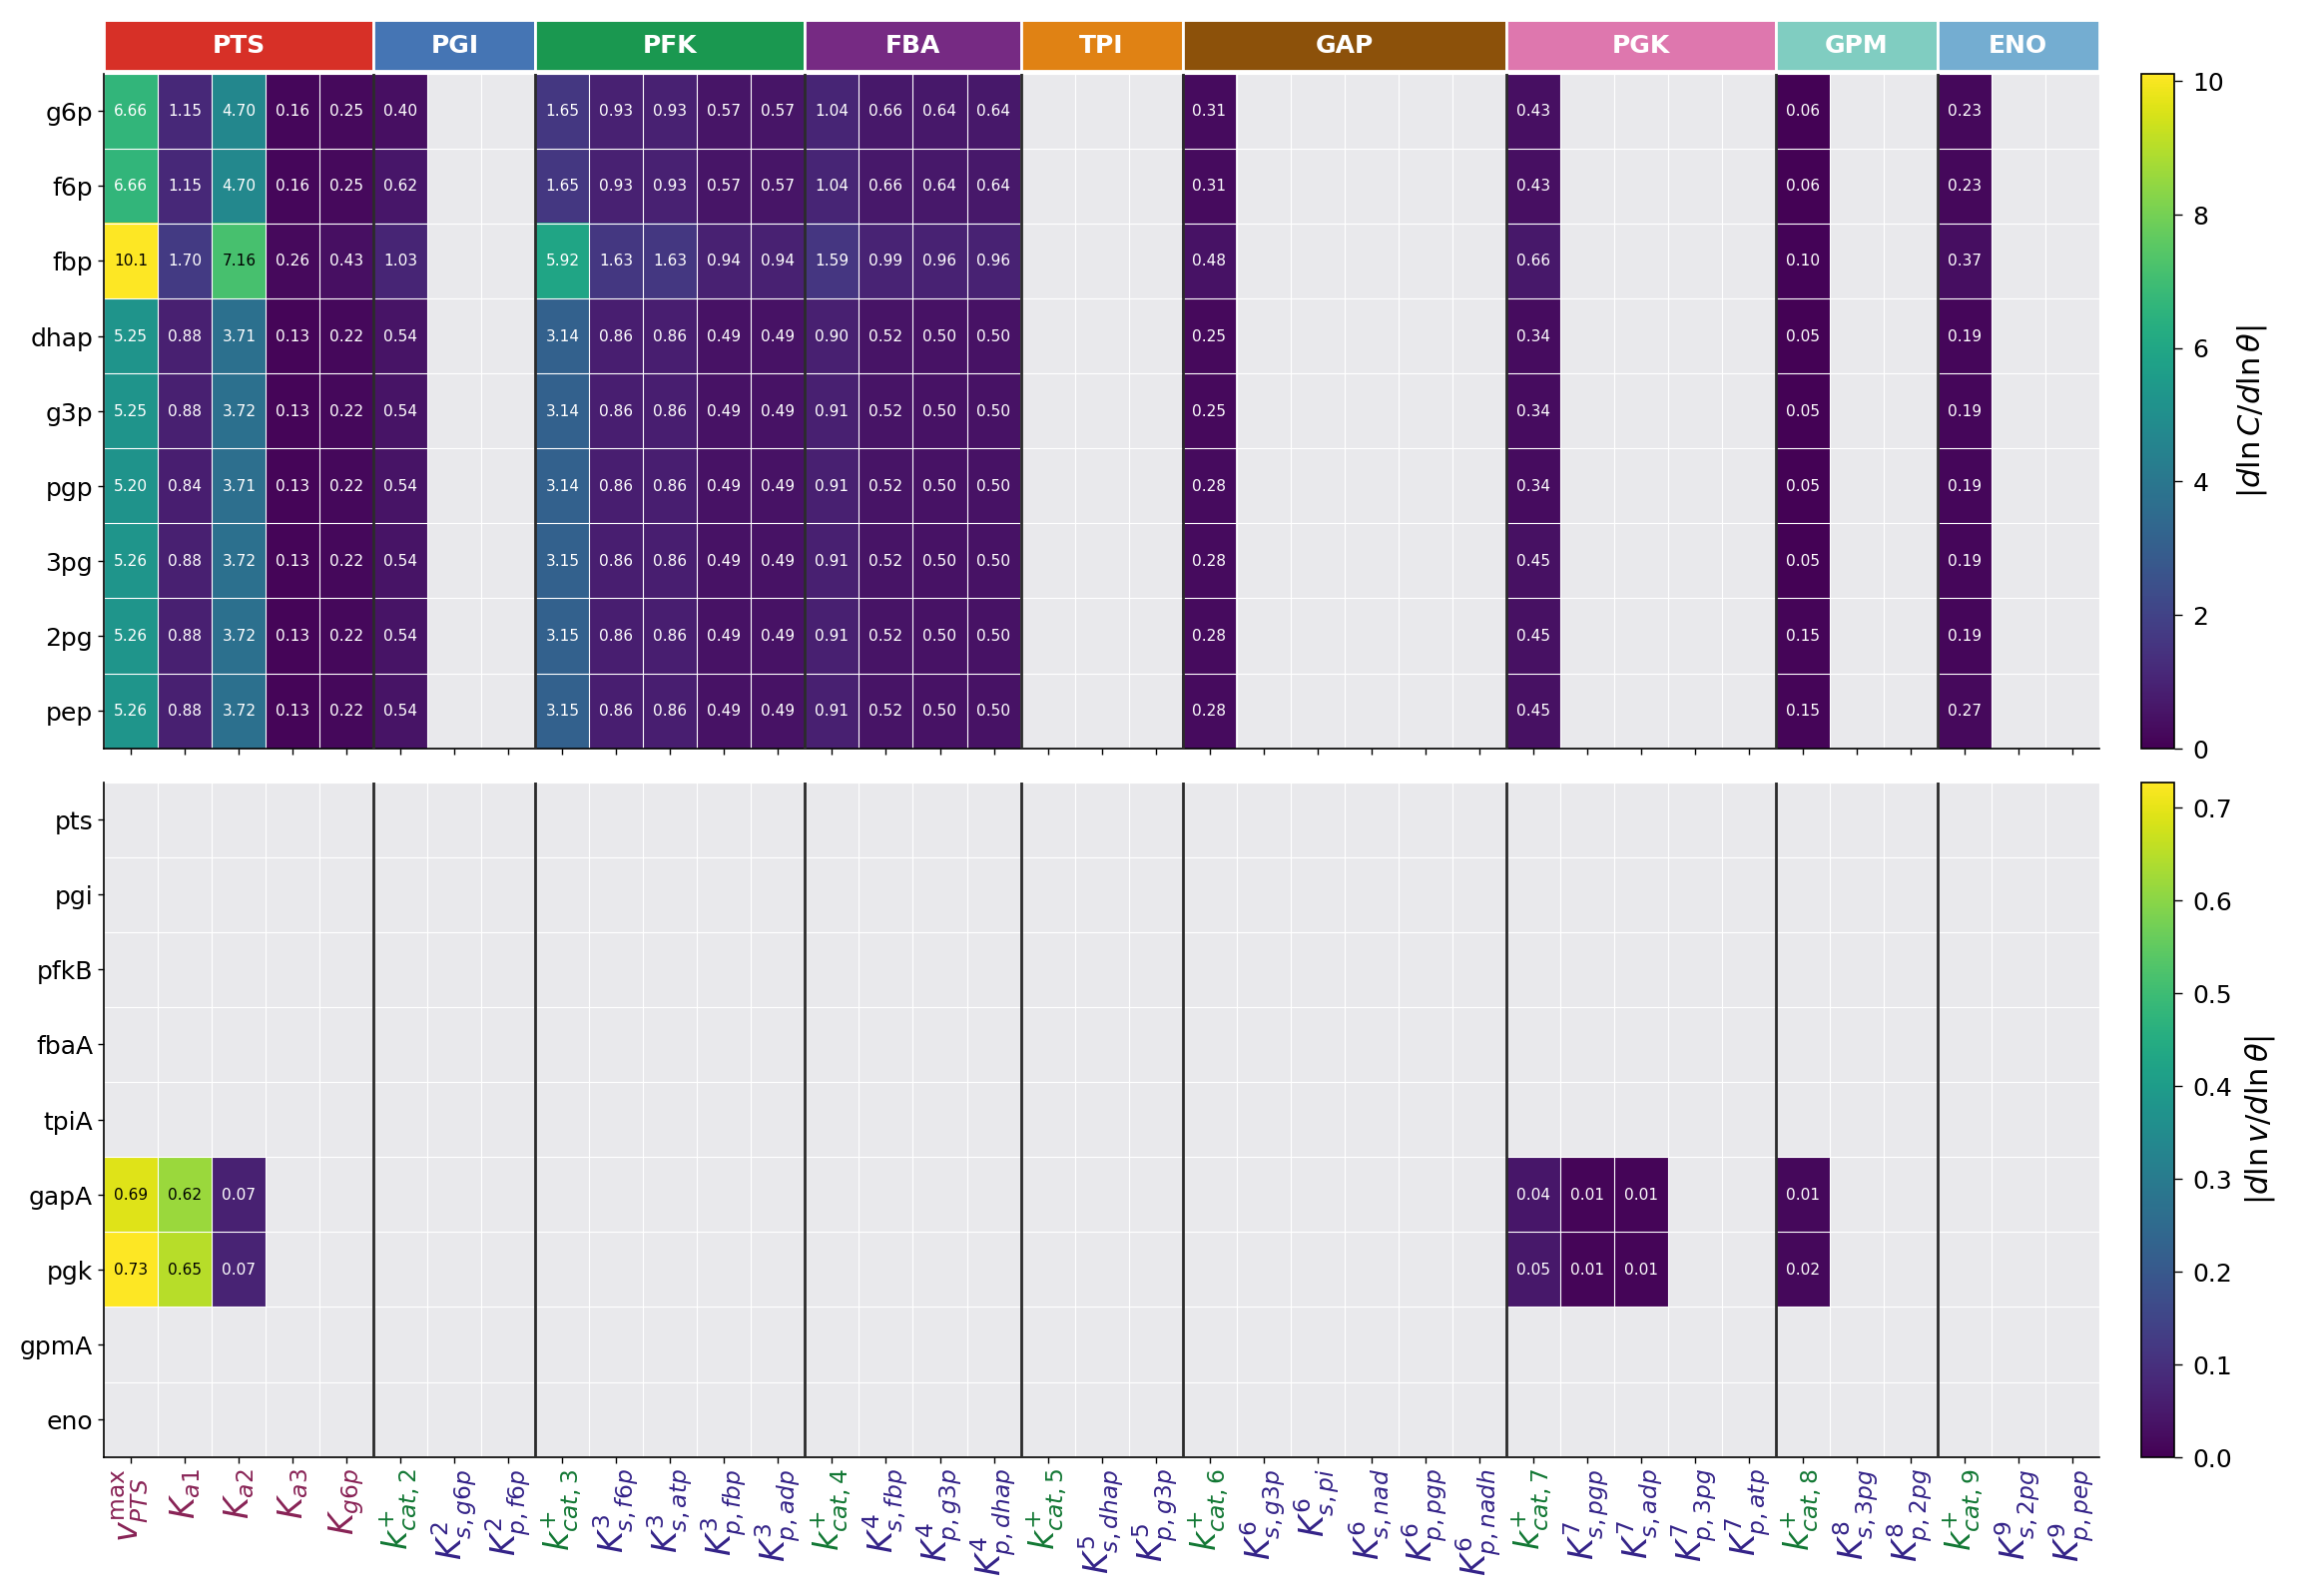

Saved: sensitivity_rel_mean.pdf
Thresholds: conc >= 0.01, flux >= 0.01
Log scale: conc=False, flux=False
Cells shown: conc 171/333, flux 14/333


In [5]:
# Sensitivity heatmap: RELATIVE mean over conditions, split concentration/flux scales
import warnings
from matplotlib.colors import LogNorm

# all 22 conditions; all 9 concentration rows now have finite model predictions.
theta_fit = pd.read_csv(RESULTS_DIR / 'theta_fitted.csv', index_col=0)['value']
pred_fit = pd.read_csv(RESULTS_DIR / 'predictions_fitted.csv', index_col=0)

theta_vec = theta_fit.reindex(param_cols).to_numpy(dtype=float)            # (37,)
pred_aligned = pred_fit.reindex(index=cond_names, columns=row_name)        # (n_cond, 18)
Y = pred_aligned.to_numpy(dtype=float)
Y = np.where((Y > 0) & np.isfinite(Y), Y, np.nan)                          # guard div

rel_stack = G_stack * theta_vec[None, None, :] / Y[:, :, None]            # (n_cond, 18, 37)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)                        # all-NaN rows
    G_rel_mean = np.nanmean(np.abs(rel_stack), axis=0)                      # (18, 37)

# Threshold: cells whose mean |relative sensitivity| is below the threshold are
# masked (rendered grey).  
SENS_THRESH_CONC = 0.01     # keeps params that move a concentration by >~10%
SENS_THRESH_FLUX = 0.01   # keeps the upper-quartile (most sensitive) flux cells

CONC_LOG_SCALE = False
FLUX_LOG_SCALE = False

# Annotate each shown (above-threshold) cell with its relative-sensitivity
# value.  Masked/grey cells are left blank.  ANNOT_FS controls text size.
ANNOTATE_VALUES = True
ANNOT_FS = 5.5

G_plot = G_rel_mean[:, _perm]              

n_par = G_plot.shape[1]
conc_block = G_plot[:9, :]
flux_block  = G_plot[9:, :]

# Apply thresholds: values below the cut become NaN (drawn with set_bad grey)
conc_block = np.where(conc_block >= SENS_THRESH_CONC, conc_block, np.nan)
flux_block = np.where(flux_block >= SENS_THRESH_FLUX, flux_block, np.nan)

def _imshow_kw(block, use_log):
    """Build imshow color kwargs: LogNorm when use_log else linear 0..max.
    The log vmin is a robust 5th-percentile floor of positive cells so a few
    tiny values do not stretch the dynamic range."""
    pos = block[np.isfinite(block) & (block > 0)]
    if pos.size == 0:
        return dict(vmin=0, vmax=1.0)
    vmax = float(pos.max())
    if use_log:
        vmin = float(np.percentile(pos, 5))
        vmin = max(min(vmin, vmax / 10.0), vmax * 1e-9)
        return dict(norm=LogNorm(vmin=vmin, vmax=vmax))
    return dict(vmin=0, vmax=vmax)

# Row labels: strip 'C_' prefix for concentration, 'v_' prefix for flux
y_labels_conc = [nm.replace('C_', '') for nm in row_name[:9]]
y_labels_flux = [nm.replace('v_', '') for nm in row_name[9:]]

TOP_STRIP_Y = 1.004
TOP_STRIP_H = 0.026
STRIP_FS = 9

mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        12,
    'axes.linewidth':   0.6,
    'mathtext.fontset': 'dejavusans',
})

fig = plt.figure(figsize=(13.5, 9.0), dpi=200)
gs = fig.add_gridspec(2, 1, height_ratios=[9, 9], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

cmap_seq = mpl.colormaps['viridis'].copy()
cmap_seq.set_bad('#e9e9ec')

im_top = ax_top.imshow(conc_block, aspect='auto', cmap=cmap_seq,
                        interpolation='none', **_imshow_kw(conc_block, CONC_LOG_SCALE))
im_bot = ax_bot.imshow(flux_block, aspect='auto', cmap=cmap_seq,
                        interpolation='none', **_imshow_kw(flux_block, FLUX_LOG_SCALE))

def _annotate_cells(ax, block, im, fs):
    """Write each finite cell's value, with text color chosen for contrast against
    the underlying viridis color (white on dark cells, black on light cells)."""
    def _fmt(v):
        if v >= 100:
            return '%.0f' % v
        if v >= 10:
            return '%.1f' % v
        return '%.2f' % v
    nrows, ncols = block.shape
    for r in range(nrows):
        for c in range(ncols):
            v = block[r, c]
            if not np.isfinite(v):
                continue
            red, grn, blu, _ = im.cmap(im.norm(v))
            lum = 0.299 * red + 0.587 * grn + 0.114 * blu
            ax.text(c, r, _fmt(v), ha='center', va='center', fontsize=fs,
                    color='white' if lum < 0.55 else 'black', zorder=6)

if ANNOTATE_VALUES:
    _annotate_cells(ax_top, conc_block, im_top, ANNOT_FS)
    _annotate_cells(ax_bot, flux_block, im_bot, ANNOT_FS)

cbar_top = fig.colorbar(im_top, ax=ax_top, fraction=0.025, pad=0.02)
cbar_top.set_label(r'$|d\ln C / d\ln\theta|$', fontsize=11, labelpad=4)
cbar_top.ax.tick_params(labelsize=9, length=3, width=0.5)
cbar_top.outline.set_linewidth(0.6)

cbar_bot = fig.colorbar(im_bot, ax=ax_bot, fraction=0.025, pad=0.02)
cbar_bot.set_label(r'$|d\ln v / d\ln\theta|$', fontsize=11, labelpad=4)
cbar_bot.ax.tick_params(labelsize=9, length=3, width=0.5)
cbar_bot.outline.set_linewidth(0.6)

ax_top.set_yticks(range(9))
ax_top.set_yticklabels(y_labels_conc, fontsize=9)
ax_bot.set_yticks(range(9))
ax_bot.set_yticklabels(y_labels_flux, fontsize=9)

plt.setp(ax_top.get_xticklabels(), visible=False)
ax_bot.set_xticks(range(n_par))
ax_bot.set_xticklabels(param_labels_p, rotation=90, fontsize=12, ha='center')
for i, t in enumerate(ax_bot.get_xticklabels()):
    t.set_color(_type_color(i))
    t.set_fontweight('semibold')
ax_bot.tick_params(length=2, width=0.5, pad=2)
ax_top.tick_params(length=2, width=0.5, pad=2)

for ax, nrows in [(ax_top, 9), (ax_bot, 9)]:
    for k in np.arange(-0.5, n_par, 1):
        ax.plot([k, k], [-0.5, nrows - 0.5], color='white', lw=0.4, zorder=1)
    for k in np.arange(-0.5, nrows, 1):
        ax.plot([-0.5, n_par - 0.5], [k, k], color='white', lw=0.4, zorder=1)

for ax in [ax_top, ax_bot]:
    for _nm, i_s, i_e, _col in reaction_groups:
        if i_s != 0:
            ax.plot([i_s - 0.5, i_s - 0.5], [-0.5, 8.5], color='#2b2b2b', lw=1.0, zorder=3)

# Top reaction strip via blended_transform_factory over ax_top
trans_top = blended_transform_factory(ax_top.transData, ax_top.transAxes)
for name, i_s, i_e, col in reaction_groups:
    ax_top.add_patch(MplRect((i_s - 0.5, TOP_STRIP_Y), i_e - i_s + 1, TOP_STRIP_H + 0.05,
                             transform=trans_top, facecolor=col, edgecolor='white',
                             lw=1.0, clip_on=False, zorder=4))
    ax_top.text((i_s + i_e) / 2, TOP_STRIP_Y + (TOP_STRIP_H + 0.05) / 2, name,
                transform=trans_top, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white',
                clip_on=False, zorder=5)

for s in ('top', 'right'):
    ax_top.spines[s].set_visible(False)
    ax_bot.spines[s].set_visible(False)

fig.savefig(FIG_DIR / 'sensitivity_rel_mean.pdf', dpi=300, bbox_inches='tight')
plt.show()

mpl.rcParams.update(mpl.rcParamsDefault)
n_shown_conc = int(np.isfinite(conc_block).sum())
n_shown_flux = int(np.isfinite(flux_block).sum())
print('Saved: sensitivity_rel_mean.pdf')
print(f'Thresholds: conc >= {SENS_THRESH_CONC}, flux >= {SENS_THRESH_FLUX}')
print(f'Log scale: conc={CONC_LOG_SCALE}, flux={FLUX_LOG_SCALE}')
print(f'Cells shown: conc {n_shown_conc}/{conc_block.size}, flux {n_shown_flux}/{flux_block.size}')

## Correlation Matrix

Parameter correlation matrix $r_{ij}$: full (unmasked) and masked ($|r| \geq 0.9$ only).

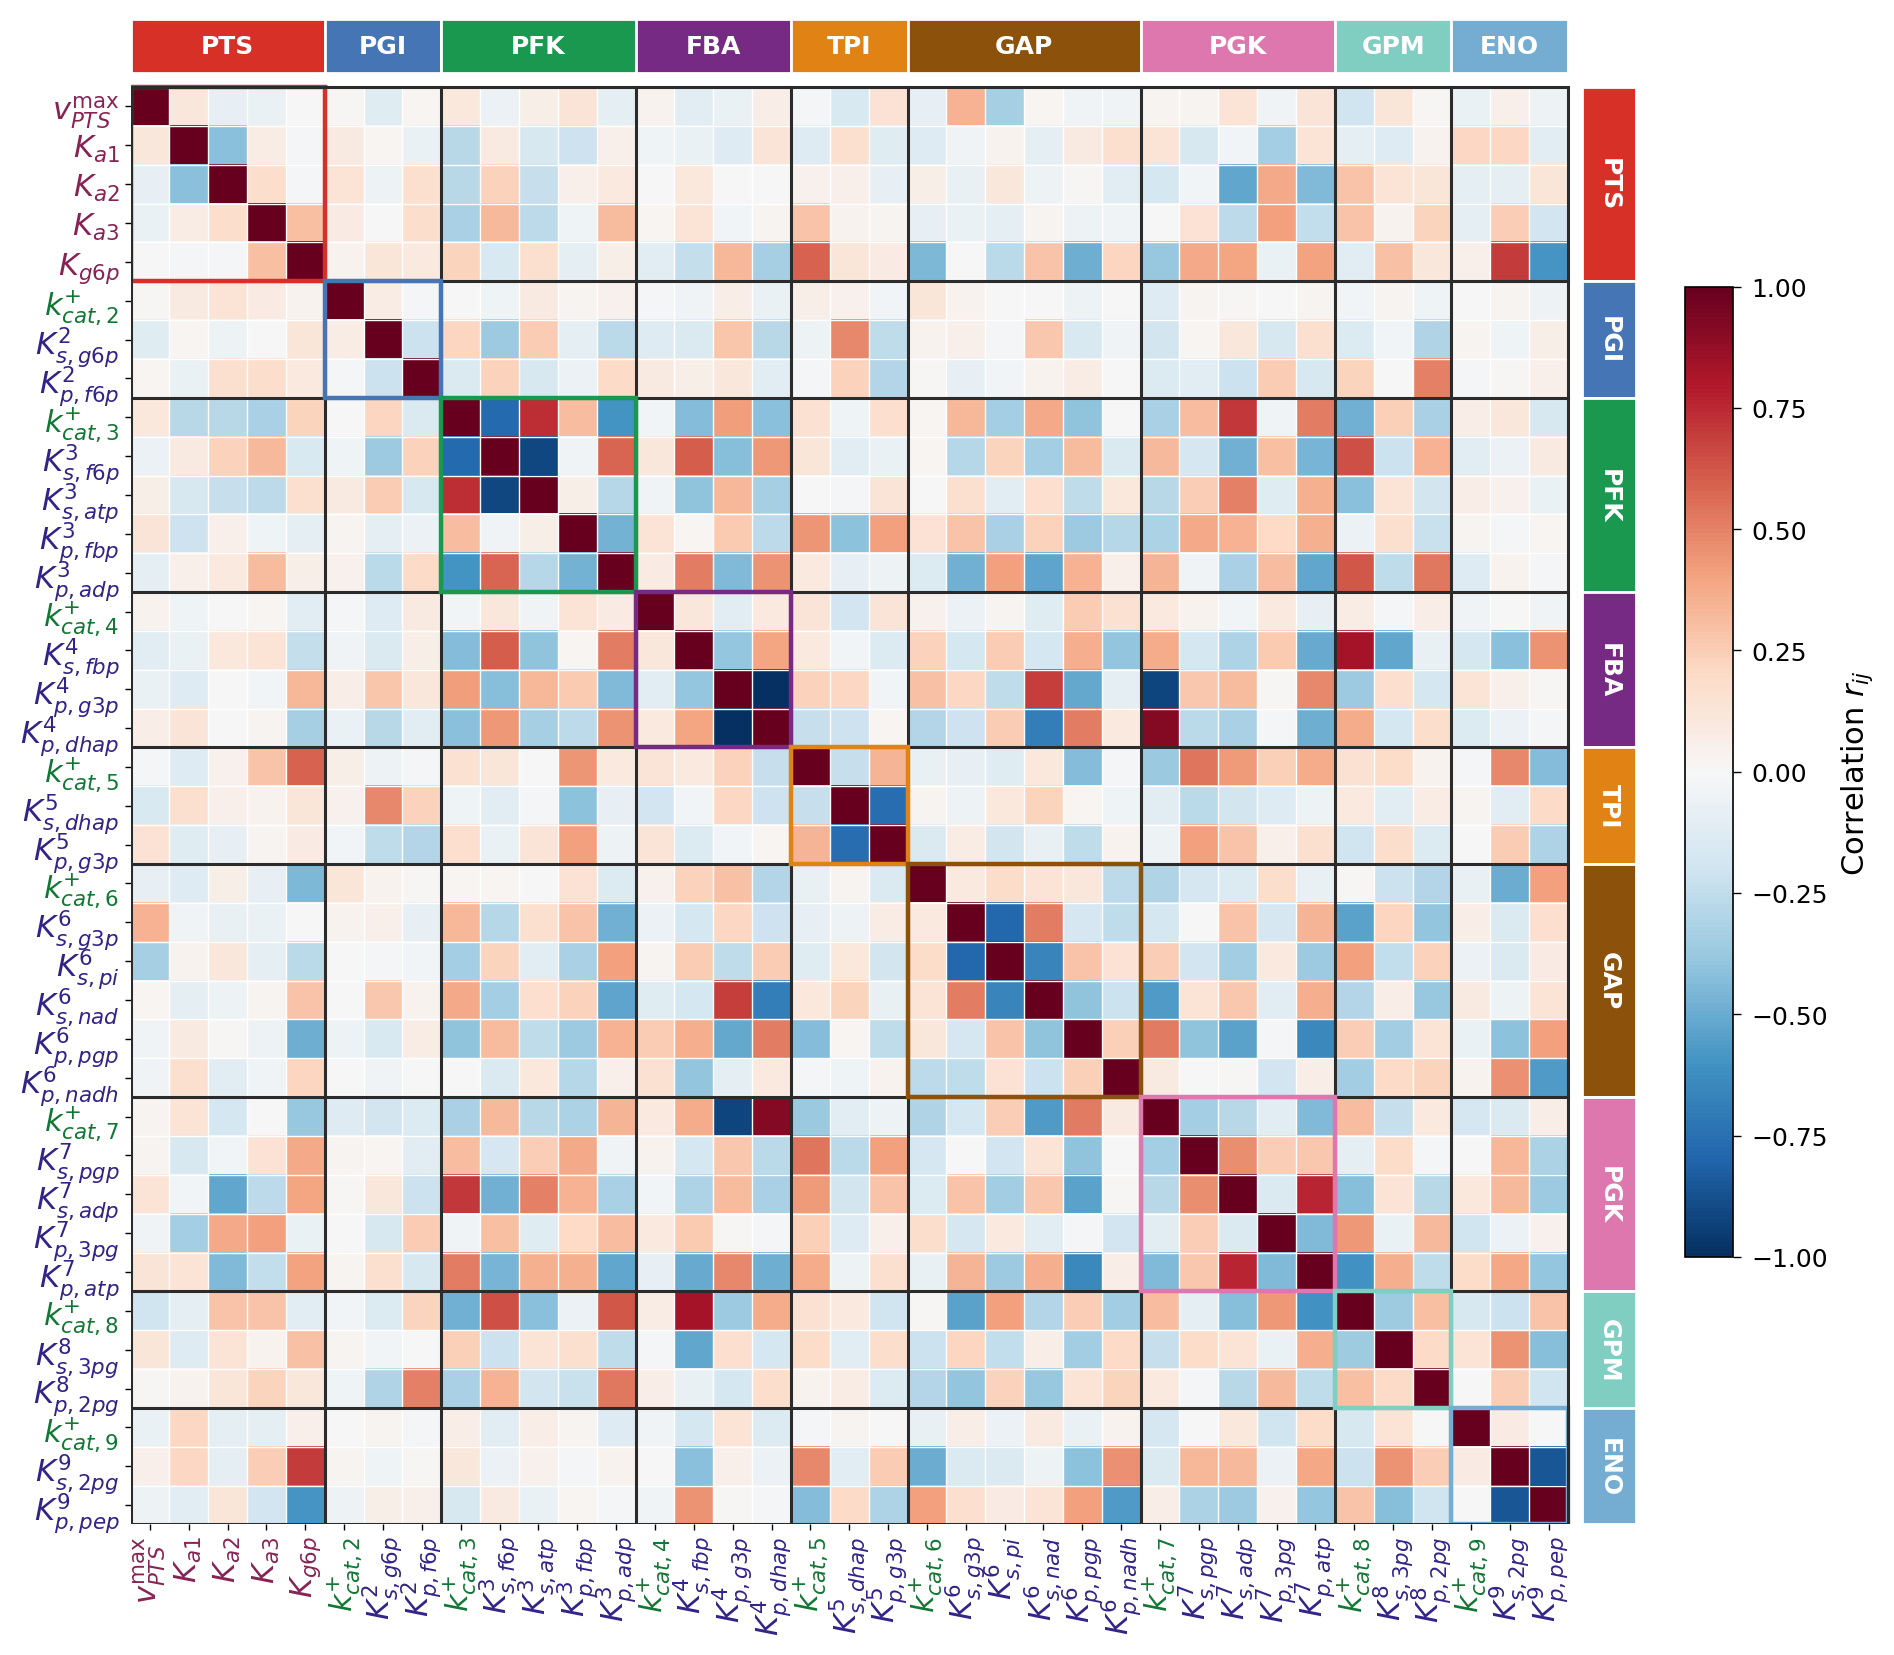

Saved: corr_not_masked.pdf


In [6]:
# Correlation heatmap, unmasked (diagonal -> NaN)
corr_p = corr_df.values[np.ix_(_perm, _perm)].copy().astype(float)

styled_matrix_heatmap(
    corr_p, -1, 1,
    r'Correlation $r_{ij}$',
    FIG_DIR / 'corr_not_masked.pdf'
)
print('Saved: corr_not_masked.pdf')

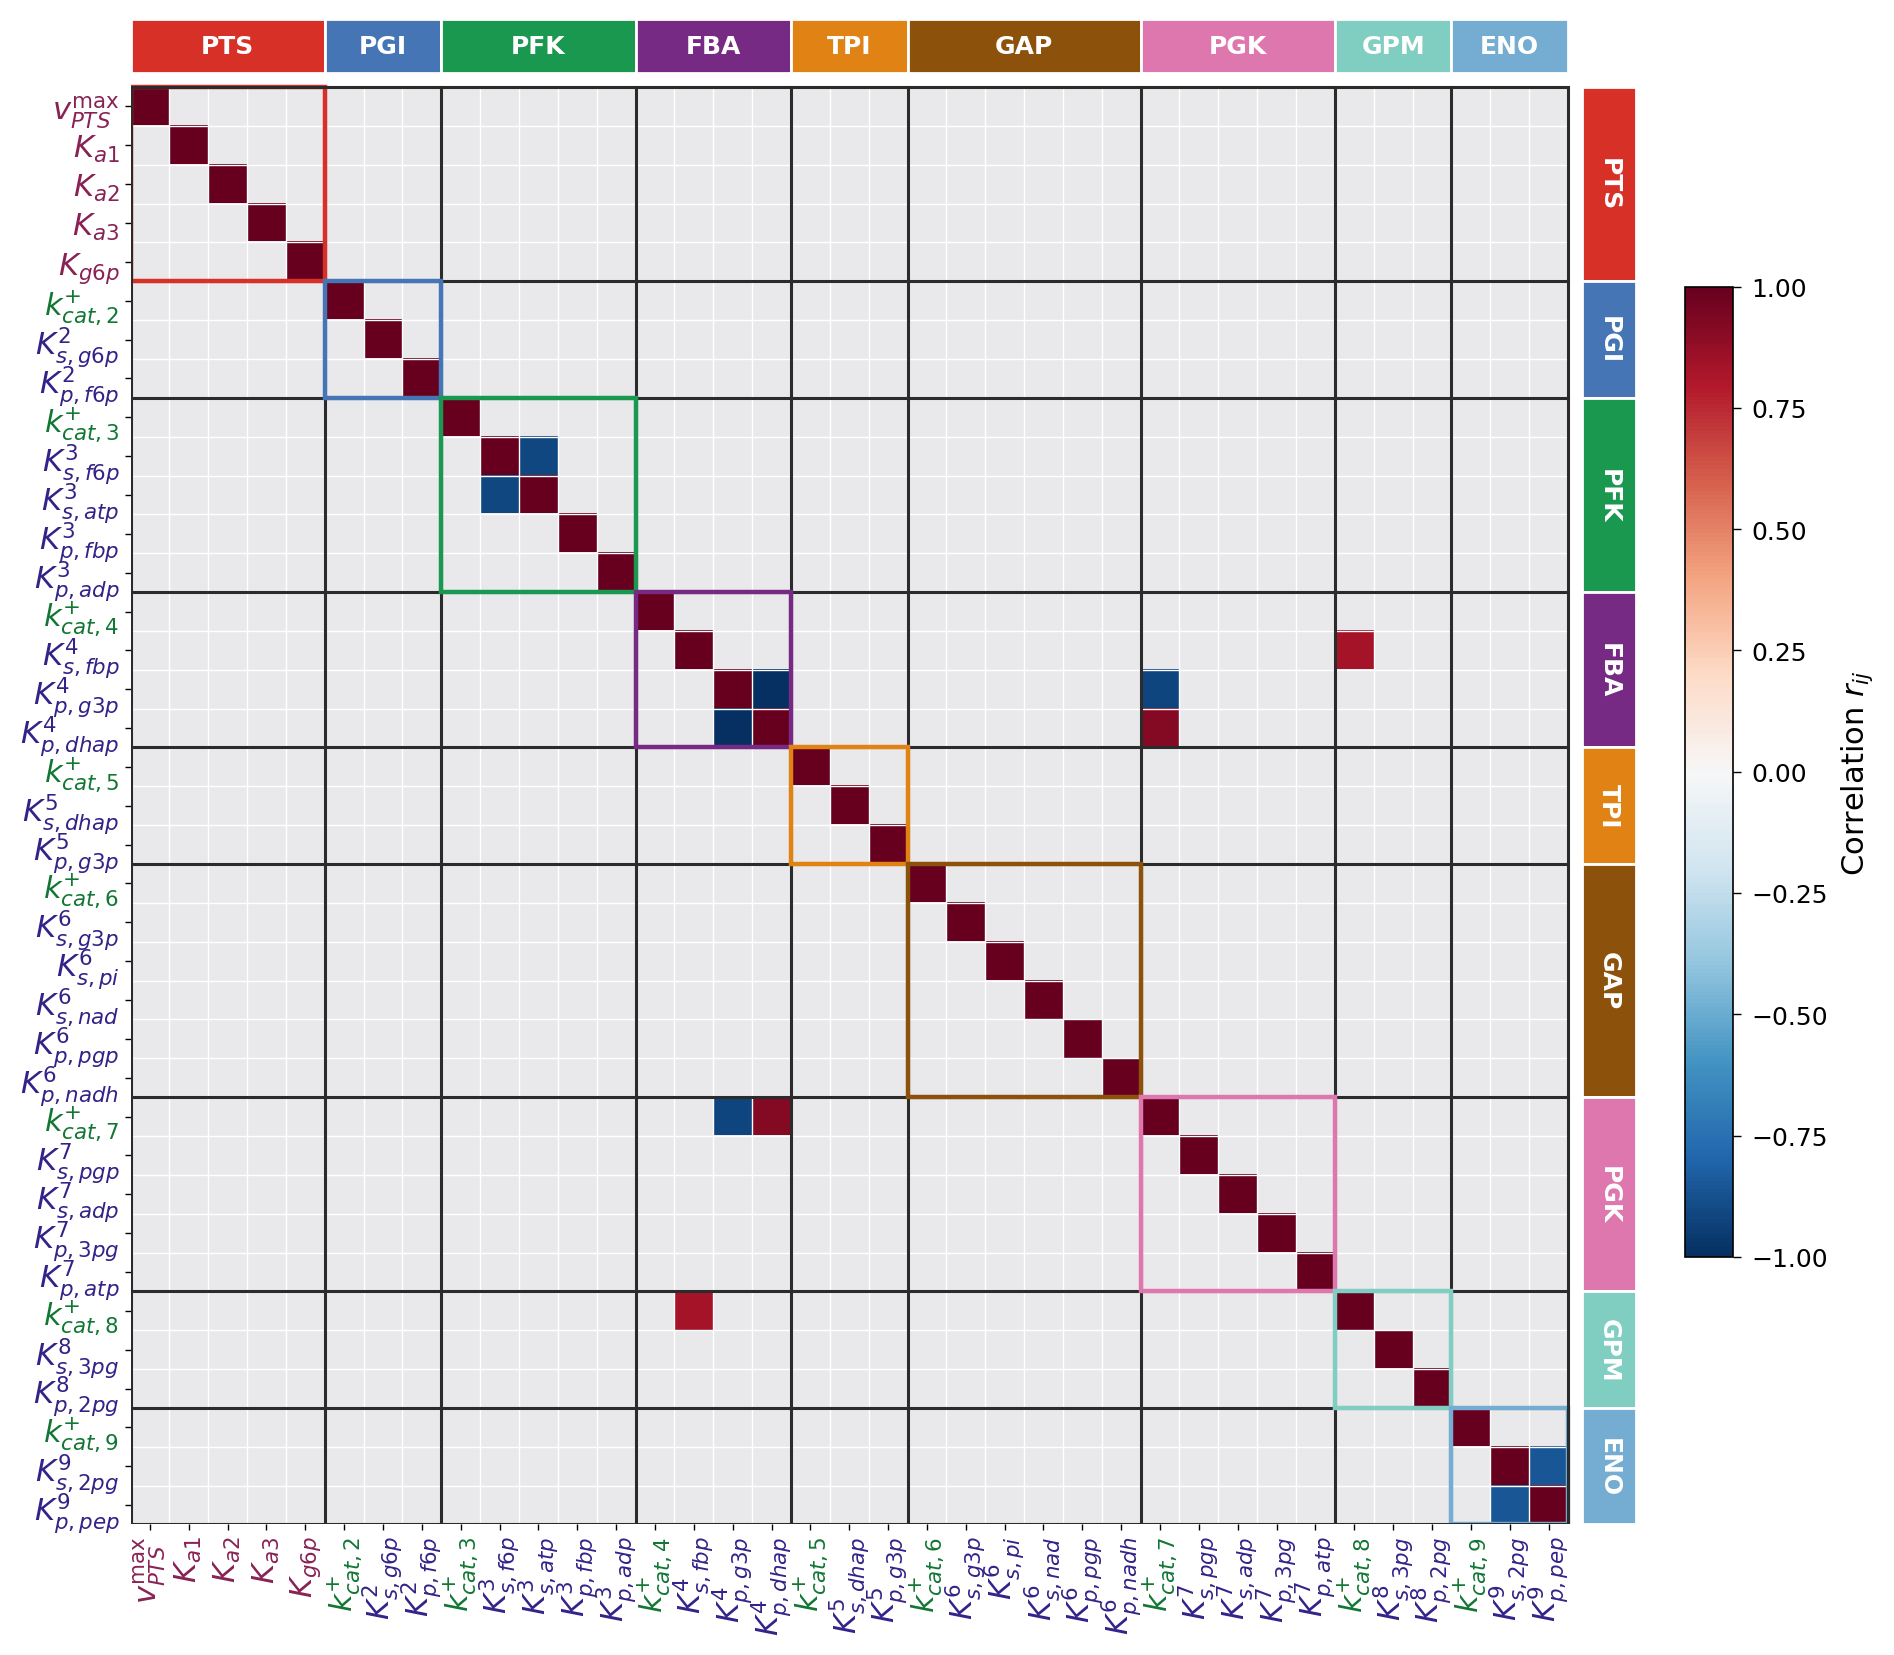

Saved: corr_masked.pdf


In [7]:
# Correlation heatmap, masked: show only |r| >= 0.9 (diagonal -> NaN)
corr_p_full = corr_df.values[np.ix_(_perm, _perm)].copy().astype(float)
corr_masked = np.where(np.abs(corr_p_full) >= 0.8, corr_p_full, np.nan)


styled_matrix_heatmap(
    corr_masked, -1, 1,
    r'Correlation $r_{ij}$',
    FIG_DIR / 'corr_masked.pdf',
    annotate=False, annot_fs=5.0
)
print('Saved: corr_masked.pdf')

# Confidence intervals: constrained vs. unconstrained ($\hat{\theta}\pm2\sigma$)

Per-parameter normalized confidence intervals split by identifiability.
**Panel 1** (green, 6 params): identifiable parameters whose CI excludes zero --
data-constrained, meaningful fitted values.
**Panel 2** (red, 31 params): non-identifiable parameters whose CI crosses zero --
sign undetermined by the data; fixed at literature values downstream.

Both panels show $(\hat{\theta}\pm2\sigma)/\hat{\theta}$: estimate sits at 1.0,
bar half-width $= 2\sigma/|\hat{\theta}|$. A bar reaching below $y=0$ confirms the
parameter is unconstrained. Panel 1 uses a linear y-axis; Panel 2 uses symlog
(linthresh=1.0) because the unconstrained half-widths span many orders of magnitude.

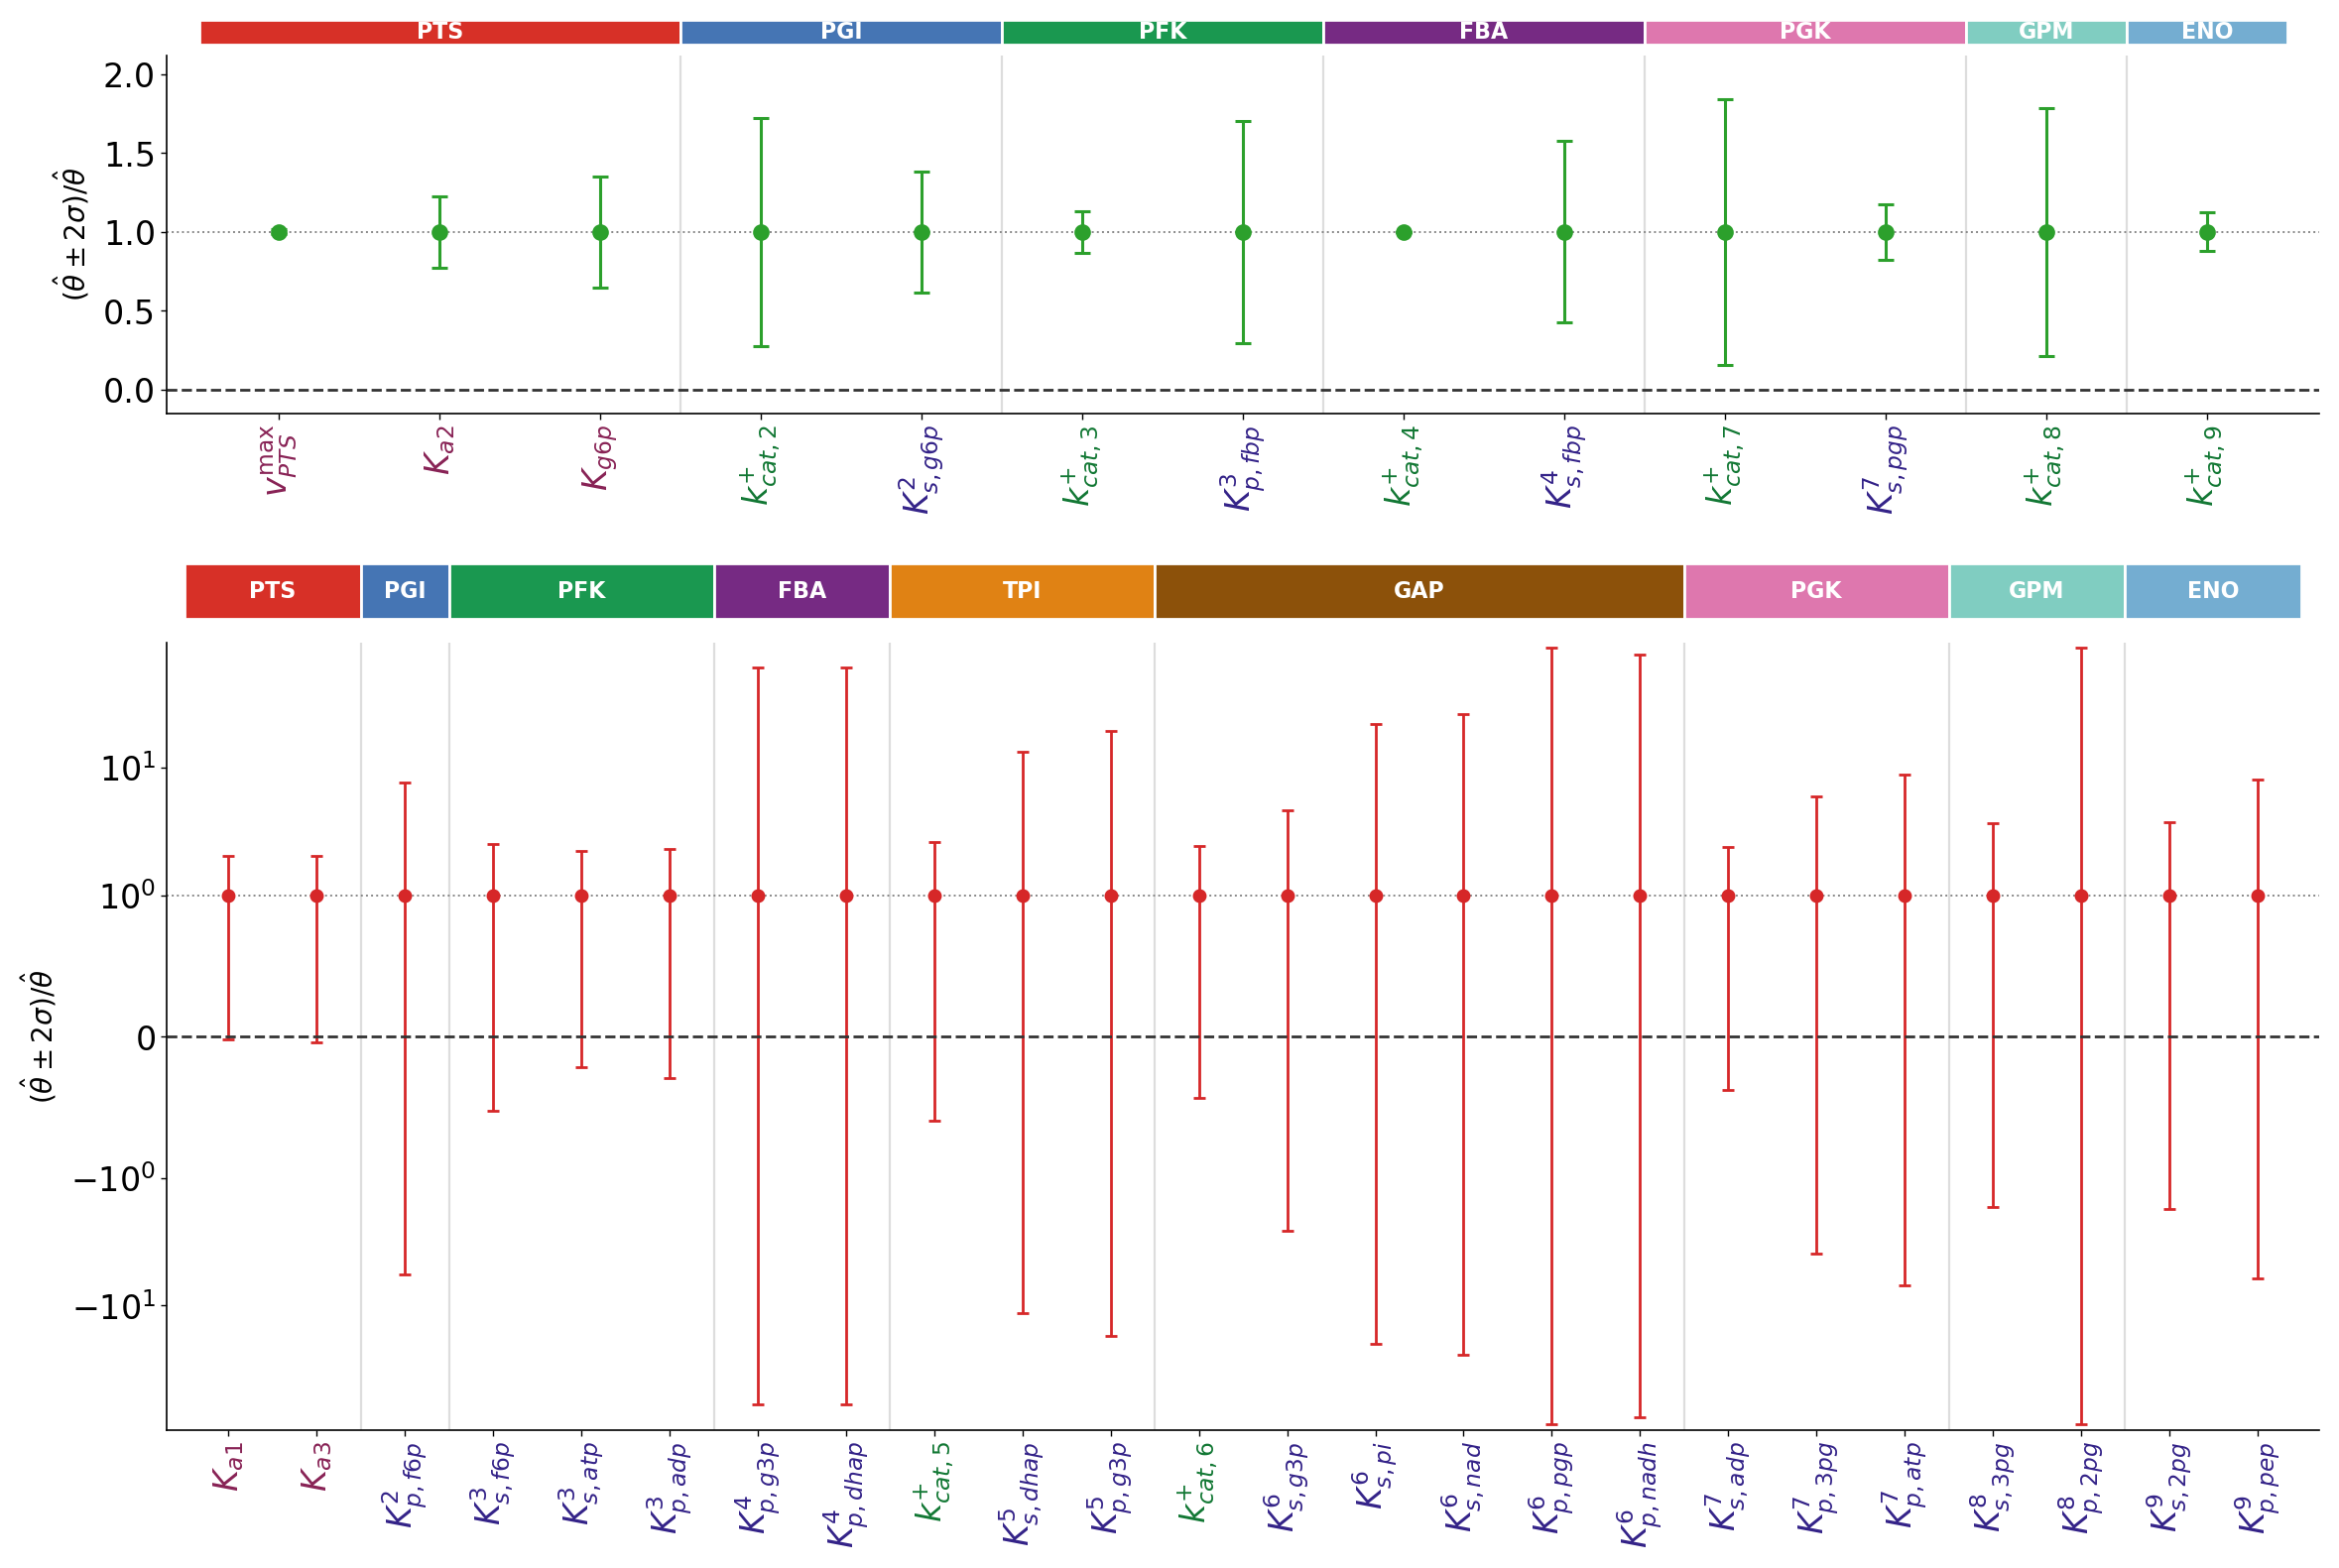

Saved: theta_ci_split.pdf
Panel 1 (constrained): 13 params; Panel 2 (unconstrained): 24 params
24/37 parameters have a CI that crosses zero.


In [8]:
# Confidence-interval split plot: constrained vs. unconstrained parameters.
#
# Panel 1 (green, 6 params): identifiable -- CI excludes zero.
# Panel 2 (red, 31 params): non-identifiable -- CI crosses zero -> fixed downstream.
# Both panels: normalized view (estimate at 1.0, bar = 2*sigma/|theta|).
# Panel 1: linear y.  Panel 2: symlog y linthresh=1.0 (CIs span many orders).
from matplotlib.lines import Line2D

order = _perm
names_ord = [PARAMS[i] for i in order]
ident_set = set(ci_ident_df.index)

theta = ci_df['theta'].iloc[order].to_numpy(dtype=float).copy()
sd = ci_df['std_err'].iloc[order].to_numpy(dtype=float).copy()
for i, nm in enumerate(names_ord):
    if nm in ident_set:
        theta[i] = float(ci_ident_df.loc[nm, 'theta'])
        sd[i] = float(ci_ident_df.loc[nm, 'std_err'])

K_SIGMA = 2
cross_mask = (theta - K_SIGMA * sd) <= 0
half = K_SIGMA * sd / np.abs(theta)

pos1 = np.where(~cross_mask)[0]   # _perm-order positions: constrained (CI excludes 0)
pos2 = np.where(cross_mask)[0]    # _perm-order positions: unconstrained (CI crosses 0)

COLOR_NOCROSS = '#2ca02c'
COLOR_CROSS = '#d62728'

def _draw_rxn_strip_and_seps(ax, pos_subset):
    local_of = {p: k for k, p in enumerate(pos_subset)}
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    STRIP_Y, STRIP_H, STRIP_FS = 1.03, 0.07, 8
    for name, i_s, i_e, col in reaction_groups:
        members = [local_of[p] for p in pos_subset if i_s <= _perm[p] <= i_e]
        if not members:
            continue
        k0, k1 = min(members), max(members)
        if k0 > 0:
            ax.axvline(k0 - 0.5, color='#dddddd', lw=0.8, zorder=0)
        ax.add_patch(MplRect((k0 - 0.5, STRIP_Y), k1 - k0 + 1, STRIP_H,
                             transform=trans, facecolor=col, edgecolor='white',
                             lw=1.0, clip_on=False, zorder=4))
        ax.text((k0 + k1) / 2, STRIP_Y + STRIP_H / 2, name, transform=trans,
                ha='center', va='center', fontsize=STRIP_FS, fontweight='bold',
                color='white', clip_on=False, zorder=5)

mpl.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 12,
    'axes.linewidth': 0.6, 'mathtext.fontset': 'dejavusans',
})

fig = plt.figure(figsize=(14.0, 9.0), dpi=200)
gs = fig.add_gridspec(2, 1, height_ratios=[1, 2.2], hspace=0.4)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# Panel 1: constrained (linear y)
x1 = np.arange(len(pos1))
for k, p in enumerate(pos1):
    ax1.errorbar(k, 1.0, yerr=half[p], fmt='o', color=COLOR_NOCROSS,
                 markerfacecolor=COLOR_NOCROSS, markeredgecolor=COLOR_NOCROSS,
                 markersize=5, capsize=3, elinewidth=1.1, capthick=1.1)
ax1.axhline(1.0, color='#888888', lw=0.7, ls=':')
ax1.axhline(0.0, color='#333333', lw=1.0, ls='--')
ax1.set_ylim(-0.15, max(float((1.0 + half[pos1]).max()) * 1.15, 1.3))
ax1.set_xticks(x1)
ticks1 = ax1.set_xticklabels([param_labels_p[p] for p in pos1], rotation=90, fontsize=12, ha='center')
for t, p in zip(ticks1, pos1):
    t.set_color(_type_color(p))
    t.set_fontweight('semibold')
ax1.set_xlim(-0.7, len(x1) - 0.3)
ax1.set_ylabel(r'$(\hat{\theta} \pm 2\sigma)/\hat{\theta}$', fontsize=10)
# ax1.set_title('Constrained parameters -- CI excludes zero', fontsize=10, pad=22)
ax1.tick_params(length=2, width=0.5, pad=2)
for s in ('top', 'right'):
    ax1.spines[s].set_visible(False)
_draw_rxn_strip_and_seps(ax1, pos1)

# Panel 2: unconstrained (symlog y)
x2 = np.arange(len(pos2))
for k, p in enumerate(pos2):
    ax2.errorbar(k, 1.0, yerr=half[p], fmt='o', color=COLOR_CROSS,
                 markerfacecolor=COLOR_CROSS, markeredgecolor=COLOR_CROSS,
                 markersize=4, capsize=2, elinewidth=1.0, capthick=1.0)
ax2.axhline(1.0, color='#888888', lw=0.7, ls=':')
ax2.axhline(0.0, color='#333333', lw=1.0, ls='--')
ax2.set_yscale('symlog', linthresh=1.0)
ax2.set_xticks(x2)
ticks2 = ax2.set_xticklabels([param_labels_p[p] for p in pos2], rotation=90, fontsize=12, ha='center')
for t, p in zip(ticks2, pos2):
    t.set_color(_type_color(p))
    t.set_fontweight('semibold')
ax2.set_xlim(-0.7, len(x2) - 0.3)
ax2.set_ylabel(r'$(\hat{\theta} \pm 2\sigma)/\hat{\theta}$', fontsize=10)
# ax2.set_title('Unconstrained parameters -- CI crosses zero (fixed downstream)', fontsize=10, pad=22)
ax2.tick_params(length=2, width=0.5, pad=2)
for s in ('top', 'right'):
    ax2.spines[s].set_visible(False)
_draw_rxn_strip_and_seps(ax2, pos2)

leg = [
    Line2D([0], [0], marker='o', color=COLOR_NOCROSS, markerfacecolor=COLOR_NOCROSS,
           markersize=6, label='CI excludes zero (constrained)'),
    Line2D([0], [0], marker='o', color=COLOR_CROSS, markerfacecolor=COLOR_CROSS,
           markersize=6, label='CI crosses zero (unconstrained, fixed downstream)'),
    Line2D([0], [0], color='#888888', lw=0.7, ls=':', label=r'estimate ($\hat{\theta}$, y=1)'),
    Line2D([0], [0], color='#333333', lw=1.0, ls='--', label='zero (y=0)'),
]
# ax1.legend(handles=leg, fontsize=8, loc='upper right', framealpha=0.9, edgecolor='#cccccc')

fig.savefig(FIG_DIR / 'theta_ci_split.pdf', dpi=300, bbox_inches='tight')
plt.show()
mpl.rcParams.update(mpl.rcParamsDefault)

n_cross = int(cross_mask.sum())
print('Saved: theta_ci_split.pdf')
print(f'Panel 1 (constrained): {len(pos1)} params; Panel 2 (unconstrained): {len(pos2)} params')
print(f'{n_cross}/{len(order)} parameters have a CI that crosses zero.')

# report

In [9]:
# Correlated-pairs LaTeX table: pairs with |r| >= 0.9
# Reconstruct param_latex from the ORIGINAL ALL_PARAMS order (= list(corr_df.columns))
all_params_orig = list(corr_df.columns)
param_latex = {k: _param_labels_orig[j] for j, k in enumerate(all_params_orig)}

pairs = []
n_params = len(all_params_orig)
corr_vals = corr_df.values

for i in range(n_params):
    for j in range(i + 1, n_params):
        r = corr_vals[i, j]
        if np.isfinite(r) and abs(r) >= 0.9:
            pairs.append({
                'param_i': param_latex[all_params_orig[i]],
                'param_j': param_latex[all_params_orig[j]],
                'r': round(r, 4)
            })

pairs_df = pd.DataFrame(pairs, columns=['param_i', 'param_j', 'r'])
pairs_df = pairs_df.sort_values('r', key=abs, ascending=False).reset_index(drop=True)

print(f'Number of correlated pairs (|r| >= 0.9) over all 37 params: {len(pairs_df)}')
print(pairs_df.to_latex(index=False))

# Context: the structural report's n_corr_pairs_ge_0.9 is NOT directly comparable.
# It counts strongly-correlated pairs only AMONG IDENTIFIABLE parameters, and it
# uses the relative-FIM pseudo-inverse correlation (sentitivity.py), not the saved
# correlation.csv used here. So a difference is expected, not a bug. For an
# apples-to-apples reference we also report the count restricted to identifiable
# params using THIS (saved) correlation matrix.
ident_params = list(struct_df.index[struct_df['identifiable'] == True])
n_ident_pairs_saved = 0
for i in range(len(ident_params)):
    for j in range(i + 1, len(ident_params)):
        r = corr_df.loc[ident_params[i], ident_params[j]]
        if np.isfinite(r) and abs(r) >= 0.9:
            n_ident_pairs_saved += 1

n_corr_report = int(ident_df['n_corr_pairs_ge_0.9'].iloc[0])
print(f'\nStructural report n_corr_pairs_ge_0.9 = {n_corr_report} '
      '(identifiable-only, relative-FIM correlation).')
print(f'Saved correlation.csv, identifiable-only: {n_ident_pairs_saved} pair(s).')
print(f'Saved correlation.csv, all params: {len(pairs_df)} pairs.')
print('These count different things, so they are not expected to be equal.')


Number of correlated pairs (|r| >= 0.9) over all 37 params: 4
\begin{tabular}{llr}
\toprule
param_i & param_j & r \\
\midrule
$K_{p,g3p}^{4}$ & $K_{p,dhap}^{4}$ & -0.999900 \\
$K_{p,g3p}^{4}$ & $k^{+}_{cat,7}$ & -0.919600 \\
$K_{p,dhap}^{4}$ & $k^{+}_{cat,7}$ & 0.919600 \\
$K_{s,f6p}^{3}$ & $K_{s,atp}^{3}$ & -0.911300 \\
\bottomrule
\end{tabular}


Structural report n_corr_pairs_ge_0.9 = 6 (identifiable-only, relative-FIM correlation).
Saved correlation.csv, identifiable-only: 0 pair(s).
Saved correlation.csv, all params: 4 pairs.
These count different things, so they are not expected to be equal.


In [10]:
# Fix-justification table: the FULL covariance (with its huge ranges) is the
# evidence for WHY the non-identifiable params are fixed downstream.  For each
# non-identifiable param (flagged by the structural FIM-rank criterion) we report
# the value it is fixed AT (theta), its std_err, variance, CV%, and whether its
# 95% CI crosses zero -- all read from the FULL covariance.  A CI that crosses
# zero or a CV% >> 100% means the data do not constrain the parameter, so it is
# held at its literature / prior value in the fix-and-reduce step.
ident_set = set(ci_ident_df.index)
non_ident = [p for p in PARAMS if p not in ident_set]

fix_tbl = ci_df.loc[non_ident, ['theta', 'std_err', 'ci_low', 'ci_high', 'cv_percent']].copy()
fix_tbl['variance'] = np.diag(cov_df.loc[non_ident, non_ident].to_numpy())
fix_tbl['ci_crosses_zero'] = (fix_tbl['ci_low'] <= 0) & (fix_tbl['ci_high'] >= 0)
fix_tbl = fix_tbl.sort_values('cv_percent', ascending=False)
fix_tbl.index.name = 'param_fixed'

out = RESULTS_DIR / 'fix_justification.csv'
fix_tbl.to_csv(out)
n_cross = int(fix_tbl['ci_crosses_zero'].sum())
print(f'Saved: {out}  ({len(fix_tbl)} parameters fixed downstream)')
print(f'Primary criterion: structural non-identifiability (FIM rank '
      f'{int(ident_df["FIM_rank"].iloc[0])} of 37).')
print(f'Corroborated by the full covariance: CV% range '
      f'{fix_tbl["cv_percent"].min():.0f}% .. {fix_tbl["cv_percent"].max():,.0f}%; '
      f'{n_cross}/{len(fix_tbl)} have a 95% CI that crosses zero.')
print()
print(fix_tbl.round(3).to_string())

Saved: results/first_estimation/fix_justification.csv  (31 parameters fixed downstream)
Primary criterion: structural non-identifiability (FIM rank 15 of 37).
Corroborated by the full covariance: CV% range 6% .. 4,353%; 23/31 have a 95% CI that crosses zero.

                theta   std_err   ci_low   ci_high  cv_percent     variance  ci_crosses_zero
param_fixed                                                                                 
Kp_pgp_6        0.408    17.770  -34.422    35.238    4352.692      315.787             True
Ks_2pg_8        0.415    17.957  -34.780    35.610    4328.809      322.436             True
Kp_nadh_6       0.413    15.837  -30.628    31.454    3831.332      250.817             True
Kp_dhap_4       0.262     7.975  -15.369    15.894    3041.014       63.603             True
Kp_g3p_4        0.000     0.003   -0.007     0.007    3031.628        0.000             True
Ks_nad_6        0.000     0.003   -0.005     0.006    1274.261        0.000             T

## Model performance: predicted vs measured (metabolites and fluxes on separate color scales)

-5.150530255999596


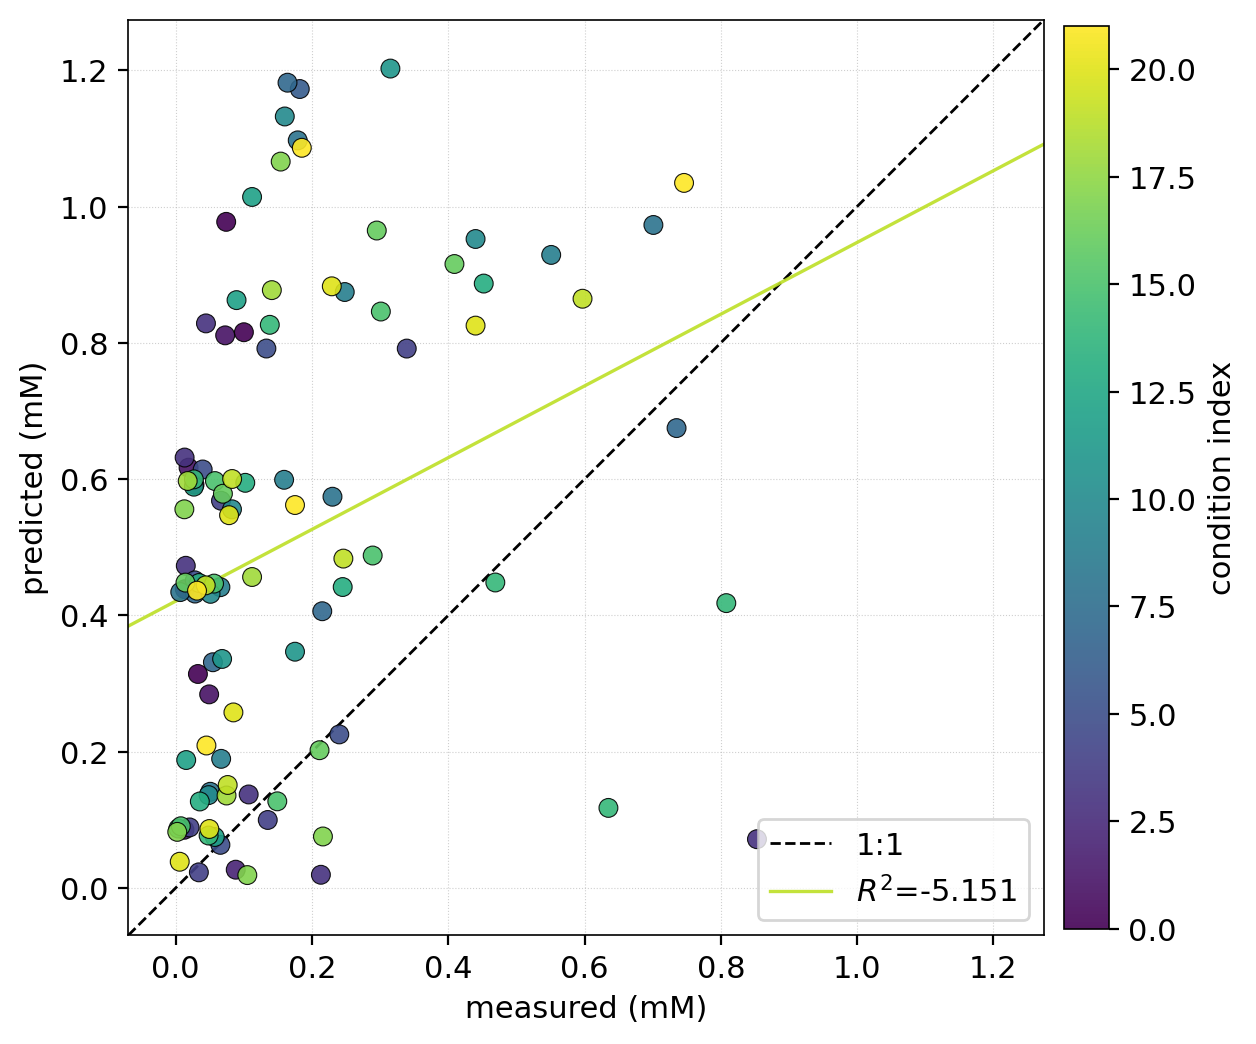

0.3072959698649105


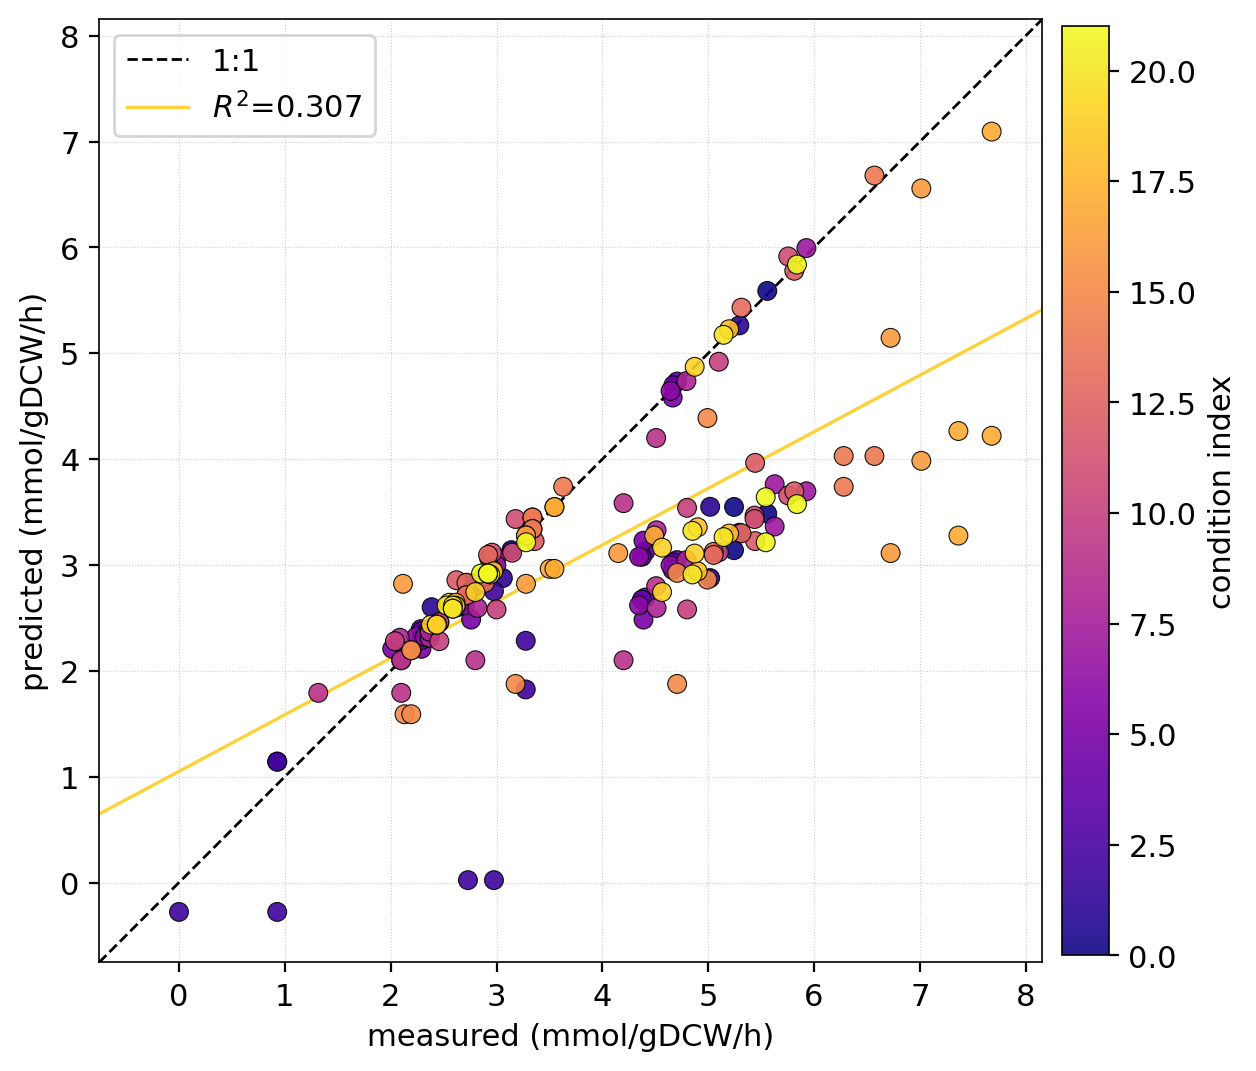

condition index -> {0: 'KO02', 1: 'KO03', 2: 'KO04', 3: 'KO05', 4: 'KO07', 5: 'KO08', 6: 'KO10', 7: 'KO11', 8: 'KO12', 9: 'KO13', 10: 'KO14', 11: 'KO15', 12: 'KO16', 13: 'KO17', 14: 'KO18', 15: 'KO19', 16: 'KO20', 17: 'KO21', 18: 'KO22', 19: 'KO23', 20: 'KO24', 21: 'RF03'}
Saved: ['parity_fitted_metabolites.pdf', 'parity_fitted_fluxes.pdf']


In [33]:
# Model performance: predicted vs measured. Metabolites and fluxes get SEPARATE
# figures (very different scales), each with its own color scale (colored by
# condition). Reads only the saved CSVs -- no re-run of the estimation needed.
from matplotlib.colors import Normalize
from scipy.stats import linregress
from sklearn.metrics import mean_squared_error, r2_score

real_df = pd.read_csv(RESULTS_DIR / 'real.csv', index_col=0)
pred_df = pd.read_csv(RESULTS_DIR / 'predictions_fitted.csv', index_col=0)

# ---- edit me -------------------------------------------------------------
# one entry per output group: (col prefix, label, colormap, log axes?, units, outfile)
GROUPS = [
    ('C_', 'Fitted model performance -- metabolites', 'viridis', False,  '(mM)',          FIG_DIR / 'parity_fitted_metabolites.pdf'),
    ('v_', 'Fitted model performance -- fluxes',      'plasma',  False, '(mmol/gDCW/h)', FIG_DIR / 'parity_fitted_fluxes.pdf'),
]
MARKER_SIZE = 46
# --------------------------------------------------------------------------

# Match the font styling used by the other plots in this notebook.
_rc_save = {k: mpl.rcParams[k] for k in (
    'font.family', 'font.size', 'axes.linewidth', 'mathtext.fontset')}
mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        11,
    'axes.linewidth':   0.6,
    'mathtext.fontset': 'dejavusans',
})

conds = [c for c in real_df.index if c in pred_df.index]
cond_to_i = {c: i for i, c in enumerate(conds)}

for prefix, label, cmap, logscale, units, outfile in GROUPS:
    group_cols = [c for c in real_df.columns if c.startswith(prefix)]
    xs, ys, cs = [], [], []
    for cond in conds:
        for col in group_cols:
            rv = real_df.loc[cond, col]
            pv = pred_df.loc[cond, col]
            if np.isfinite(rv) and np.isfinite(pv):
                xs.append(float(rv)); ys.append(float(pv)); cs.append(cond_to_i[cond])
    x, y, c = np.array(xs), np.array(ys), np.array(cs)

    fig, ax = plt.subplots(figsize=(6.4, 6.0), dpi=200)
    if logscale and x.size:
        keep = (x > 0) & (y > 0)          # log axes need positive values
        x, y, c = x[keep], y[keep], c[keep]

    sc = ax.scatter(x, y, c=c, cmap=cmap, norm=Normalize(0, max(len(conds) - 1, 1)),
                    s=MARKER_SIZE, edgecolor='k', linewidth=0.4, alpha=0.9, zorder=3)
    lo = min(x.min(), y.min()); hi = max(x.max(), y.max())
    if logscale:
        lo2, hi2 = lo / 1.4, hi * 1.4
        ax.set_xscale('log'); ax.set_yscale('log')
    else:
        pad = (hi - lo) * 0.06 or 0.1
        lo2, hi2 = lo - pad, hi + pad
    ax.plot([lo2, hi2], [lo2, hi2], 'k--', lw=1, zorder=2, label='1:1')
    ax.set_xlim(lo2, hi2)
    ax.set_ylim(lo2, hi2)
    ax.set_aspect('equal', adjustable='box')

    # Metrics in the SAME space as plotted (log for metabolites, linear for fluxes).
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    colors = plt.get_cmap(cmap)
    r2 = r2_score(x, y)
    print(r2)
    ax.plot([lo2, hi2], [slope * lo2 + intercept, slope * hi2 + intercept], lw=1.2, zorder=2,
             label=f'$R^2$={r2:.3f}',
             c = colors(0.9), alpha=0.9, linestyle='-')

    ax.set_xlabel('measured ' + units); ax.set_ylabel('predicted ' + units)
    ax.grid(True, which='both', ls=':', lw=0.4, alpha=0.6)
    ax.legend(loc='best')
    cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
    cb.set_label('condition index')
    fig.tight_layout()
    fig.savefig(outfile, dpi=300, bbox_inches='tight')
    plt.show()

mpl.rcParams.update(_rc_save)
print('condition index ->', {i: c for i, c in enumerate(conds)})
print('Saved:', [str(g[5].name) for g in GROUPS])
